In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv('IRIS.csv')

print("Dataset Loaded Successfully!")

df.head()

Dataset Loaded Successfully!


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information")
df.info()

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
display(df.describe())

Shape of Dataset:
(150, 5)

Column Names:
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Missing Values
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Statistical Summary


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


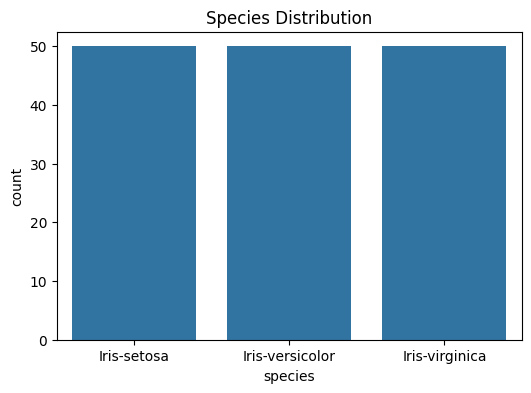

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='species', data=df)

plt.title("Species Distribution")
plt.show()

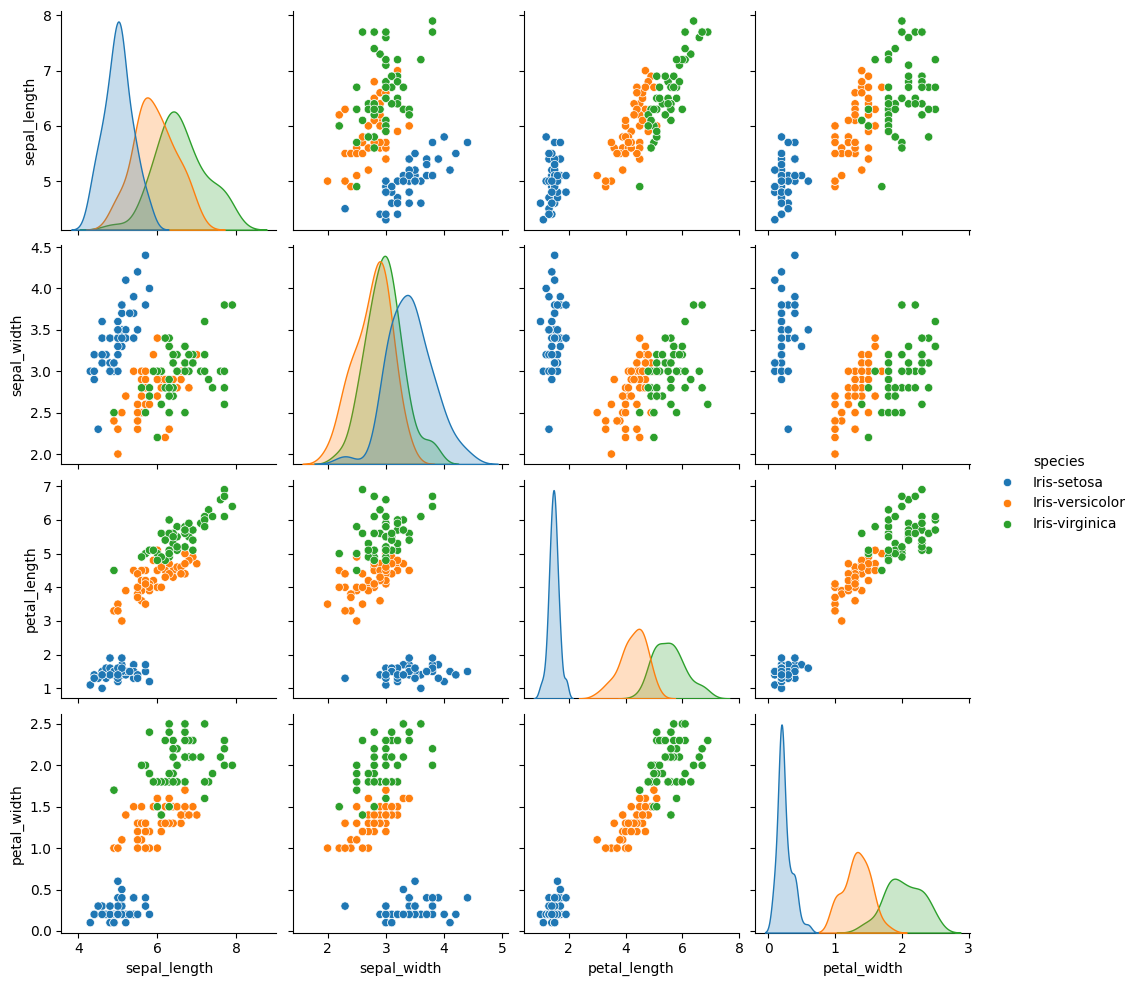

In [ ]:
sns.pairplot(df, hue='species')

plt.show()

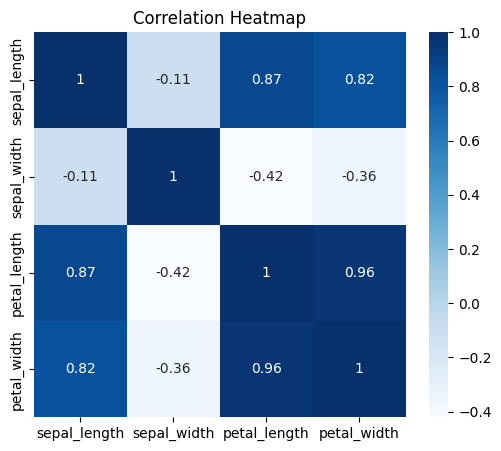

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(df.drop("species", axis=1).corr(),
            annot=True,
            cmap="Blues")

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
X = df.drop('species', axis=1)

y = df['species']

print("Features Shape :", X.shape)

print("Target Shape :", y.shape)

Features Shape : (150, 4)
Target Shape : (150,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

print("Training Samples :", len(X_train))

print("Testing Samples :", len(X_test))

Training Samples : 120
Testing Samples : 30


In [ ]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:10])

['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor']


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 1.0


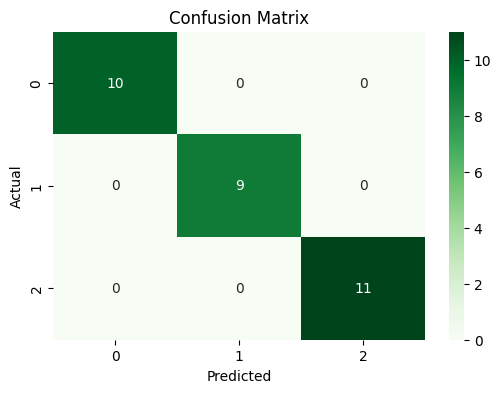

In [ ]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



        Feature  Importance
2  petal_length    0.906143
3   petal_width    0.077186
1   sepal_width    0.016670
0  sepal_length    0.000000


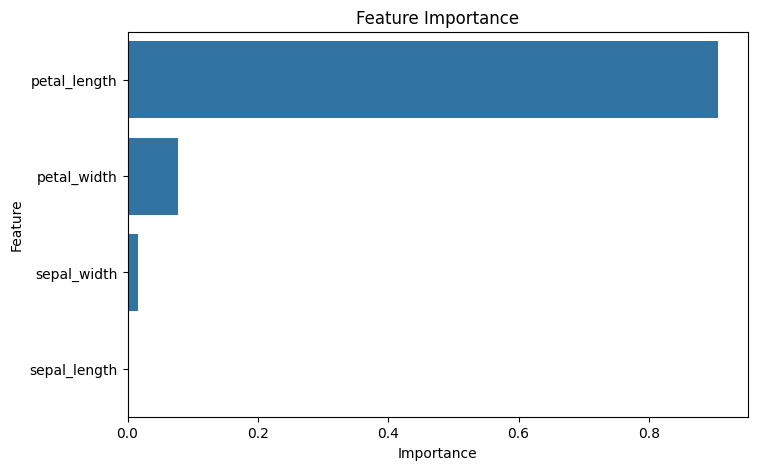

In [ ]:
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': model.feature_importances_

})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

plt.figure(figsize=(8,5))

sns.barplot(data=importance,
            x='Importance',
            y='Feature')

plt.title("Feature Importance")

plt.show()

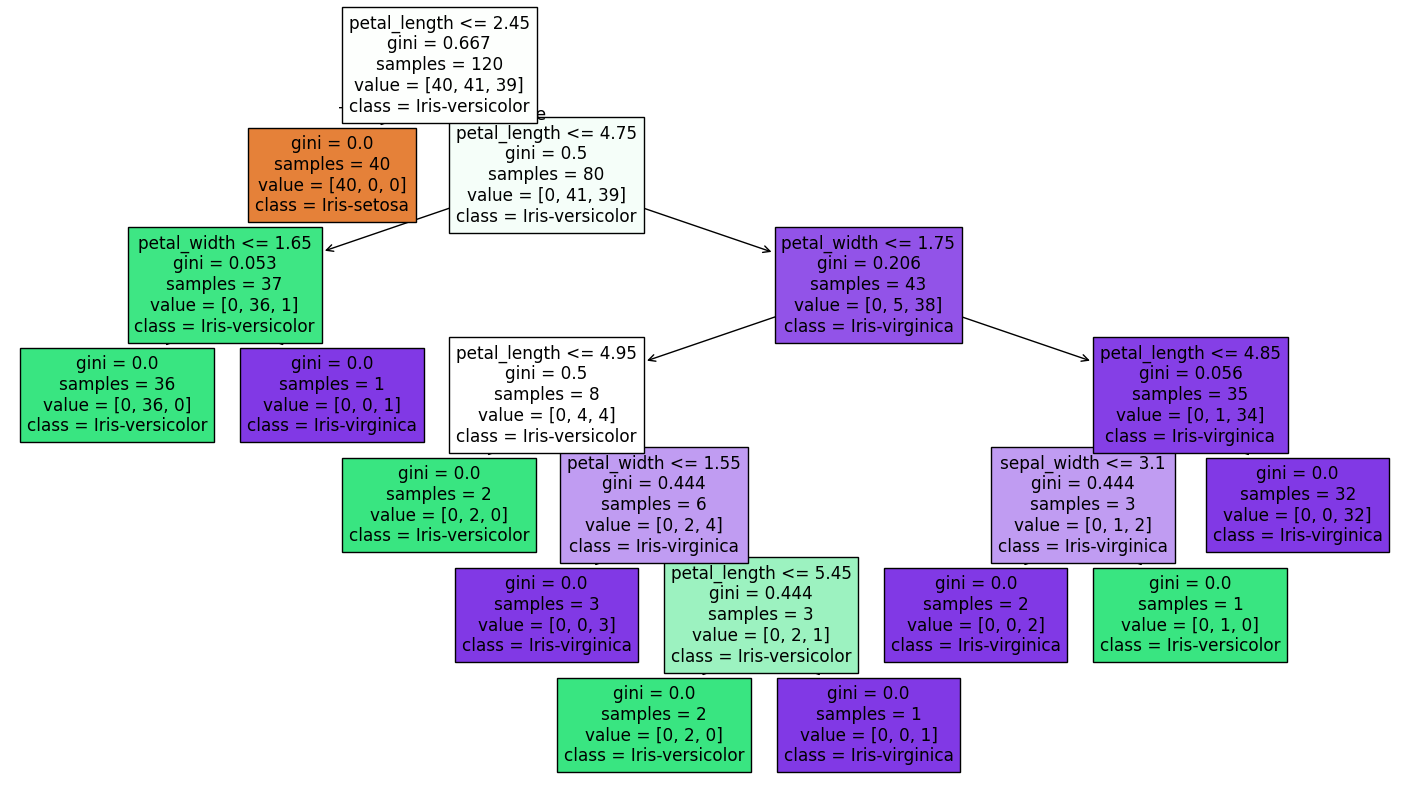

In [ ]:
#DECISION TREE
plt.figure(figsize=(18,10))

plot_tree(model,
          feature_names=X.columns,
          class_names=model.classes_,
          filled=True)

plt.show()

In [ ]:
# NEW PREDICTION
sample = [[5.1,3.5,1.4,0.2]]

prediction = model.predict(sample)

print("Predicted Species :", prediction[0])

Predicted Species : Iris-setosa


In [ ]:
joblib.dump(model,"iris_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully
